In [1]:
import torch
print(torch.__version__)

2.5.1+cu121


In [2]:
x = torch.randn(2, 3, 4)
print(f"Shape: {x.shape}")

Shape: torch.Size([2, 3, 4])


In [3]:
# %%
import torch

x = torch.randn(2, 10, 64)  # (batch, seq_len, d_model)
print(f"Original: {x.shape}")

# %%
# Simulate splitting into 8 heads
x_heads = x.view(2, 10, 8, 8)  # (batch, seq, num_heads, d_k)
print(f"After view: {x_heads.shape}")

# %%
# Transpose for attention
x_heads = x_heads.transpose(1, 2)  # (batch, num_heads, seq, d_k)
print(f"After transpose: {x_heads.shape}")


Original: torch.Size([2, 10, 64])
After view: torch.Size([2, 10, 8, 8])
After transpose: torch.Size([2, 8, 10, 8])


Shape: torch.Size([100, 64])
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  6.8156e-01,  ...,  1.0000e+00,
          1.3335e-04,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  9.9748e-01,  ...,  1.0000e+00,
          2.6670e-04,  1.0000e+00],
        ...,
        [ 3.7961e-01, -9.2515e-01, -4.6453e-01,  ...,  9.9985e-01,
          1.2935e-02,  9.9992e-01],
        [-5.7338e-01, -8.1929e-01, -9.4349e-01,  ...,  9.9985e-01,
          1.3068e-02,  9.9991e-01],
        [-9.9921e-01,  3.9821e-02, -9.1628e-01,  ...,  9.9985e-01,
          1.3201e-02,  9.9991e-01]])


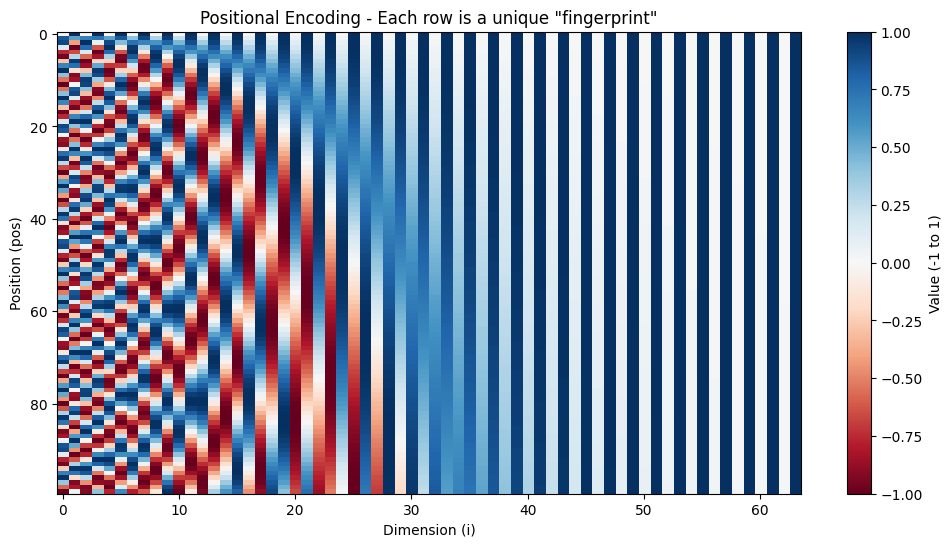

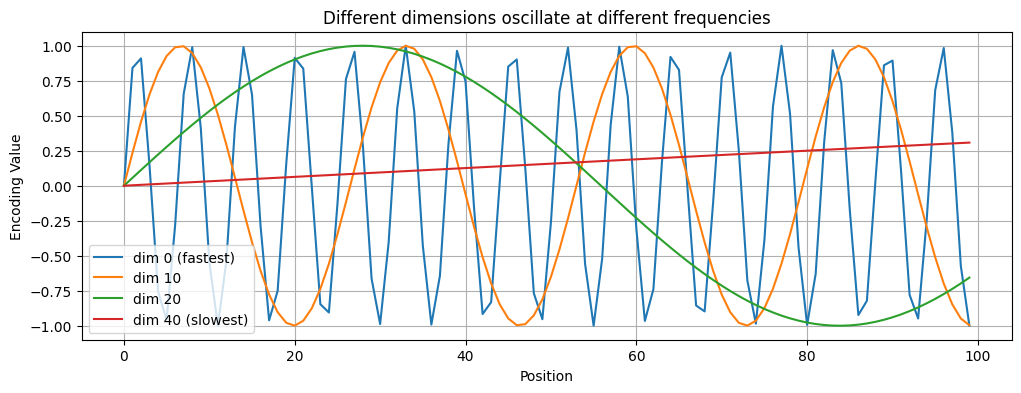

Position 0: [0. 1. 0. 1. 0. 1. 0. 1.]
Position 1: [0.841 0.54  0.682 0.732 0.533 0.846 0.409 0.912]
Position 2: [ 0.909 -0.416  0.997  0.071  0.902  0.431  0.747  0.665]
Position 50: [-0.262  0.965 -0.203  0.979  0.157 -0.988  0.787 -0.617]


In [6]:
# %%
import torch
import math
import matplotlib.pyplot as plt

# %%
# Create positional encoding from scratch
def get_positional_encoding(max_seq_len, d_model):
    """
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    pe = torch.zeros(max_seq_len, d_model)
    
    position = torch.arange(0, max_seq_len).unsqueeze(1)  # (max_seq_len, 1)
    
    # Compute the divisor: 10000^(2i/d_model)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)  # even indices
    pe[:, 1::2] = torch.cos(position * div_term)  # odd indices
    
    return pe

# %%
# Generate encoding for 100 positions, 64 dimensions
pe = get_positional_encoding(max_seq_len=100, d_model=64)
print(f"Shape: {pe.shape}")  # (100, 64)
print(pe)

# %%
# Visualize: each row is a position, each column is a dimension
plt.figure(figsize=(12, 6))
plt.imshow(pe.numpy(), cmap='RdBu', aspect='auto')
plt.xlabel('Dimension (i)')
plt.ylabel('Position (pos)')
plt.title('Positional Encoding - Each row is a unique "fingerprint"')
plt.colorbar(label='Value (-1 to 1)')
plt.show()

# %%
# Look at specific dimensions - they oscillate at different frequencies
plt.figure(figsize=(12, 4))
positions = range(100)

plt.plot(positions, pe[:, 0], label='dim 0 (fastest)')
plt.plot(positions, pe[:, 10], label='dim 10')
plt.plot(positions, pe[:, 20], label='dim 20')
plt.plot(positions, pe[:, 40], label='dim 40 (slowest)')

plt.xlabel('Position')
plt.ylabel('Encoding Value')
plt.title('Different dimensions oscillate at different frequencies')
plt.legend()
plt.grid(True)
plt.show()

# %%
# Key insight: each position has a UNIQUE encoding
print("Position 0:", pe[0, :8].numpy().round(3))
print("Position 1:", pe[1, :8].numpy().round(3))
print("Position 2:", pe[2, :8].numpy().round(3))
print("Position 50:", pe[50, :8].numpy().round(3))
